In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

drive_path = '/content/drive/MyDrive/ppi/ppi' # Updated path to look inside the nested 'ppi' directory

# Check if the directory exists
if not os.path.exists(drive_path):
    print(f"The directory '{drive_path}' does not exist.")
else:
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"[DIR] {item}")
        else:
            print(f"[FILE] {item}")

Contents of '/content/drive/MyDrive/ppi/ppi':
[FILE] ppi-feats.npy
[FILE] ppi-class_map.json
[FILE] ppi-G.json
[FILE] ppi-id_map.json
[FILE] ppi-walks.txt


### Unsupervised Training for GraphSAGE_Mean (Feature Reconstruction)

For unsupervised learning, we'll train the `GraphSAGE_Mean` model to reconstruct its input features. This means the output dimension of the model will be the same as the input feature dimension. We will use Mean Squared Error (MSE) as the loss function.

In [9]:
model_mean_unsupervised = GraphSAGE_Pool(
    in_dim=features.shape[1],
    hidden_dim=128,  # Using the same hidden dimension as before
    out_dim=features.shape[1]  # Output dimension for feature reconstruction
).to(device)

optimizer_mean_unsupervised = torch.optim.Adam(model_mean_unsupervised.parameters(), lr=0.001)
loss_fn_mean_unsupervised = torch.nn.MSELoss()

mean_unsupervised_losses = []

print("Starting unsupervised training for GraphSAGE_Pool (Feature Reconstruction)...")
for epoch in range(200):
    model_mean_unsupervised.train()
    out_unsupervised = model_mean_unsupervised(features, adj)

    # Loss is between the reconstructed features (output) and the original features (target)
    loss = loss_fn_mean_unsupervised(out_unsupervised, features)

    optimizer_mean_unsupervised.zero_grad()
    loss.backward()
    optimizer_mean_unsupervised.step()

    mean_unsupervised_losses.append(loss.item())
    print(f"Epoch {epoch} (Pool Unsupervised) | Loss: {loss.item():.6f}")

final_loss_mean_unsupervised = mean_unsupervised_losses[-1]
print(f"\nFinal MSE Loss for GraphSAGE_Pool (Unsupervised): {final_loss_mean_unsupervised:.6f}")

Starting unsupervised training for GraphSAGE_Pool (Feature Reconstruction)...
Epoch 0 (Pool Unsupervised) | Loss: 0.020337
Epoch 1 (Pool Unsupervised) | Loss: 0.019429
Epoch 2 (Pool Unsupervised) | Loss: 0.018716
Epoch 3 (Pool Unsupervised) | Loss: 0.018149
Epoch 4 (Pool Unsupervised) | Loss: 0.017708
Epoch 5 (Pool Unsupervised) | Loss: 0.017384
Epoch 6 (Pool Unsupervised) | Loss: 0.017167
Epoch 7 (Pool Unsupervised) | Loss: 0.017021
Epoch 8 (Pool Unsupervised) | Loss: 0.016895
Epoch 9 (Pool Unsupervised) | Loss: 0.016746
Epoch 10 (Pool Unsupervised) | Loss: 0.016564
Epoch 11 (Pool Unsupervised) | Loss: 0.016361
Epoch 12 (Pool Unsupervised) | Loss: 0.016154
Epoch 13 (Pool Unsupervised) | Loss: 0.015952
Epoch 14 (Pool Unsupervised) | Loss: 0.015756
Epoch 15 (Pool Unsupervised) | Loss: 0.015561
Epoch 16 (Pool Unsupervised) | Loss: 0.015362
Epoch 17 (Pool Unsupervised) | Loss: 0.015153
Epoch 18 (Pool Unsupervised) | Loss: 0.014933
Epoch 19 (Pool Unsupervised) | Loss: 0.014702
Epoch 20 (Po

### Unsupervised Training for GraphSAGE_LSTM (Feature Reconstruction)

Similarly, we'll apply unsupervised learning to the `GraphSAGE_LSTM` model, now featuring `GRUCell` layers for a recurrent update mechanism, by training it to reconstruct its input features using MSE loss.

In [10]:
model_gcn_unsupervised = GraphSAGE_LSTM(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=features.shape[1] # Output dimension for feature reconstruction
).to(device)

optimizer_gcn_unsupervised = torch.optim.Adam(model_gcn_unsupervised.parameters(), lr=0.001)
loss_fn_gcn_unsupervised = torch.nn.MSELoss()

gcn_unsupervised_losses = [

]

print("Starting unsupervised training for GraphSAGE_LSTM (Feature Reconstruction)...")
for epoch in range(30):
    model_gcn_unsupervised.train()
    out_unsupervised = model_gcn_unsupervised(features, adj)

    # Loss is between the reconstructed features (output) and the original features (target)
    loss = loss_fn_gcn_unsupervised(out_unsupervised, features)

    optimizer_gcn_unsupervised.zero_grad()
    loss.backward()
    optimizer_gcn_unsupervised.step()

    gcn_unsupervised_losses.append(loss.item())
    print(f"Epoch {epoch} (LSTM Unsupervised) | Loss: {loss.item():.6f}")



final_loss_gcn_unsupervised = gcn_unsupervised_losses[-1]
print(f"\nFinal MSE Loss for GraphSAGE_LSTM (Unsupervised): {final_loss_gcn_unsupervised:.6f}")

Starting unsupervised training for GraphSAGE_LSTM (Feature Reconstruction)...
Epoch 0 (LSTM Unsupervised) | Loss: 0.021057
Epoch 1 (LSTM Unsupervised) | Loss: 0.020394
Epoch 2 (LSTM Unsupervised) | Loss: 0.019851
Epoch 3 (LSTM Unsupervised) | Loss: 0.019405
Epoch 4 (LSTM Unsupervised) | Loss: 0.019045
Epoch 5 (LSTM Unsupervised) | Loss: 0.018766
Epoch 6 (LSTM Unsupervised) | Loss: 0.018568
Epoch 7 (LSTM Unsupervised) | Loss: 0.018440
Epoch 8 (LSTM Unsupervised) | Loss: 0.018354
Epoch 9 (LSTM Unsupervised) | Loss: 0.018275
Epoch 10 (LSTM Unsupervised) | Loss: 0.018179
Epoch 11 (LSTM Unsupervised) | Loss: 0.018065
Epoch 12 (LSTM Unsupervised) | Loss: 0.017944
Epoch 13 (LSTM Unsupervised) | Loss: 0.017826
Epoch 14 (LSTM Unsupervised) | Loss: 0.017715
Epoch 15 (LSTM Unsupervised) | Loss: 0.017612
Epoch 16 (LSTM Unsupervised) | Loss: 0.017513
Epoch 17 (LSTM Unsupervised) | Loss: 0.017417
Epoch 18 (LSTM Unsupervised) | Loss: 0.017324
Epoch 19 (LSTM Unsupervised) | Loss: 0.017232
Epoch 20 (LS

### Comparison of Unsupervised Losses

Here are the final unsupervised (feature reconstruction) losses for both models:

In [11]:
try:
    print(f"Final MSE Loss for GraphSAGE_Pool (Unsupervised): {final_loss_mean_unsupervised:.6f}")
except NameError:
    print("Error: 'final_loss_mean_unsupervised' is not defined. Please ensure the GraphSAGE_Pool unsupervised training cell (cell 686259d2) has been run successfully.")

print(f"Final MSE Loss for GraphSAGE_LSTM (Unsupervised): {final_loss_gcn_unsupervised:.6f}")

Final MSE Loss for GraphSAGE_Pool (Unsupervised): 0.000031
Final MSE Loss for GraphSAGE_LSTM (Unsupervised): 0.016417


### Plotting Unsupervised Training Losses

Let's visualize how the MSE loss evolved during unsupervised training for both models.

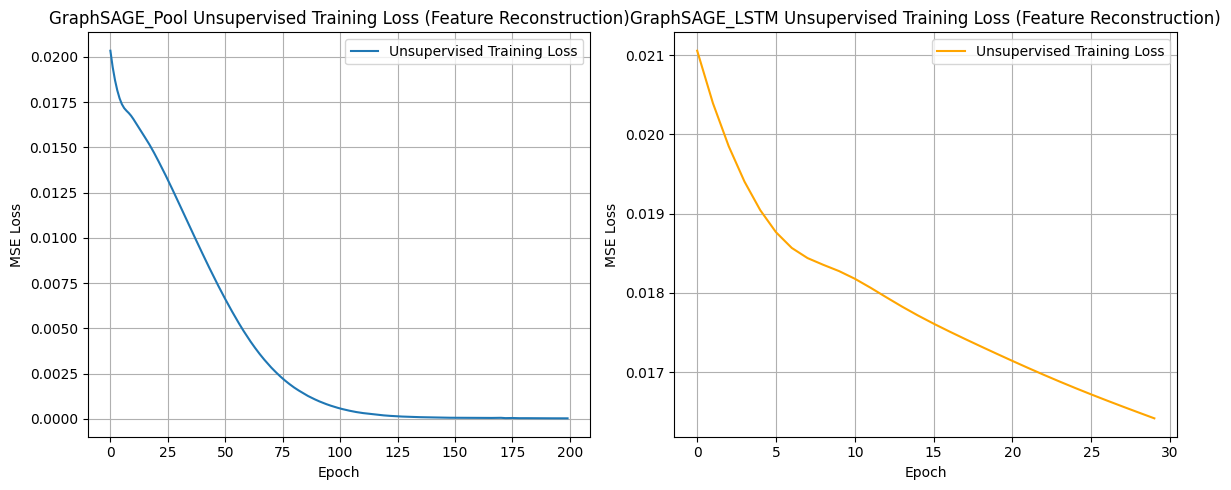

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plotting loss for GraphSAGE_Pool Unsupervised
plt.subplot(1, 2, 1)
try:
    plt.plot(mean_unsupervised_losses, label='Unsupervised Training Loss')
    plt.title('GraphSAGE_Pool Unsupervised Training Loss (Feature Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
except NameError:
    plt.text(0.5, 0.5, 'Error: mean_unsupervised_losses not defined. Run cell 686259d2 first.', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='red')
    plt.title('GraphSAGE_Pool Unsupervised Training Loss (Feature Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

# Plotting loss for GraphSAGE_LSTM Unsupervised
plt.subplot(1, 2, 2)
try:
    plt.plot(gcn_unsupervised_losses, label='Unsupervised Training Loss', color='orange')
    plt.title('GraphSAGE_LSTM Unsupervised Training Loss (Feature Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
except NameError:
    plt.text(0.5, 0.5, 'Error: gcn_unsupervised_losses not defined. Run cell 79dd70ae first.', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='red')
    plt.title('GraphSAGE_LSTM Unsupervised Training Loss (Feature Reconstruction)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()

In [8]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_Pool(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # Two distinct linear layers for aggregation to handle different input dimensions
        self.pool_fc_layer1 = nn.Linear(in_dim, hidden_dim)
        self.pool_fc_layer2 = nn.Linear(hidden_dim, hidden_dim)

        # Final transformations, adjusting fc2 input dimension as neighbor aggregation now outputs hidden_dim
        self.fc1 = nn.Linear(in_dim + hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim + hidden_dim, out_dim)

    def aggregate(self, x_input, adj, layer_idx):
        # Apply appropriate MLP for the current layer
        if layer_idx == 1:
            x_transformed = F.relu(self.pool_fc_layer1(x_input))
        elif layer_idx == 2:
            x_transformed = F.relu(self.pool_fc_layer2(x_input))
        else:
            raise ValueError("Invalid layer_idx for aggregation")

        # Use sparse matrix multiplication for mean aggregation to prevent OutOfMemoryError
        # adj is assumed to be row-normalized, so sparse.mm performs mean aggregation
        neigh = torch.sparse.mm(adj, x_transformed)
        return neigh

    def forward(self, x, adj):
        # First layer aggregation
        neigh1 = self.aggregate(x, adj, layer_idx=1)
        h = torch.cat([x, neigh1], dim=1)
        h = F.relu(self.fc1(h))

        # Second layer aggregation
        neigh2 = self.aggregate(h, adj, layer_idx=2)
        h = torch.cat([h, neigh2], dim=1)
        h = self.fc2(h)

        return h

In [7]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_LSTM(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # LSTM layer for aggregating neighbor features
        self.lstm = nn.LSTM(in_dim, hidden_dim, batch_first=True)
        # Final linear layer after concatenating self and aggregated neighbor features
        self.fc = nn.Linear(in_dim + hidden_dim, out_dim)

    def aggregate(self, x, adj):
        N = adj.size(0)
        neigh_embeddings = []

        # Extract row and column indices from the sparse adjacency matrix
        # This avoids operations like adj[i] > 0 which are not implemented for SparseCUDA
        row_indices, col_indices = adj._indices()

        # Build an adjacency list as a dictionary for efficient neighbor lookup
        # This ensures compatibility with sparse CUDA tensors by processing indices directly
        adj_list_dict = {i: [] for i in range(N)}
        # Convert indices to lists on CPU for dictionary construction
        for r, c in zip(row_indices.tolist(), col_indices.tolist()):
            adj_list_dict[r].append(c)

        for i in range(N):
            neighbors = adj_list_dict[i]

            if not neighbors: # Handle nodes with no neighbors
                neigh_embeddings.append(torch.zeros(self.lstm.hidden_size, device=x.device))
                continue

            # Gather features of neighbors using their indices
            neighbors_tensor = torch.tensor(neighbors, device=x.device, dtype=torch.long)
            neigh_feats = x[neighbors_tensor]  # Shape: [num_neighbors, in_dim]

            # Add batch dimension for LSTM input (expected: [batch_size, seq_len, input_size])
            neigh_feats = neigh_feats.unsqueeze(0) # Shape: [1, num_neighbors, in_dim]

            # Pass neighbor features through LSTM
            _, (h_n, _) = self.lstm(neigh_feats)
            # h_n shape: [1, 1, hidden_size]. Squeeze to get [hidden_size]
            neigh_embeddings.append(h_n.squeeze())

        # Stack all neighbor embeddings to form the aggregated feature matrix
        return torch.stack(neigh_embeddings)

    def forward(self, x, adj):
        # Perform aggregation for the first layer
        neigh = self.aggregate(x, adj)
        # Concatenate self features with aggregated neighbor features
        h = torch.cat([x, neigh], dim=1)
        # Apply final linear transformation
        h = self.fc(h)
        return h

In [5]:
import numpy as np
import json
import torch
import scipy.sparse # Import scipy.sparse for efficient degree calculation

data_dir = "/content/drive/MyDrive/ppi/ppi"

# features
features = np.load(f"{data_dir}/ppi-feats.npy")

# graph
with open(f"{data_dir}/ppi-G.json") as f:
    graph = json.load(f)

# id map
with open(f"{data_dir}/ppi-id_map.json") as f:
    id_map = json.load(f)

# labels
with open(f"{data_dir}/ppi-class_map.json") as f:
    class_map = json.load(f)

print("features shape:", features.shape)

num_nodes = len(id_map)

# --- Sparse Adjacency Matrix Construction and Normalization ---
row_indices = []
col_indices = []
degrees = np.zeros(num_nodes, dtype=np.float32)

# Collect edges and calculate degrees
for edge in graph["links"]:
    src = id_map[str(edge["source"])]
    dst = id_map[str(edge["target"])]

    # Add both directions for an undirected graph
    row_indices.append(src)
    col_indices.append(dst)
    degrees[src] += 1

    row_indices.append(dst)
    col_indices.append(src)
    degrees[dst] += 1

# Calculate inverse degrees for normalization: 1/degree
inv_degrees = np.where(degrees > 0, 1.0 / degrees, 0.0)

# Apply normalization to the data values
# Each entry (row_idx, col_idx) will have a value of 1/degree[row_idx]
normalized_values = [inv_degrees[row_indices[k]] for k in range(len(row_indices))]

# Create sparse COO tensor
adj_indices = torch.tensor([row_indices, col_indices], dtype=torch.long)
adj_values = torch.tensor(normalized_values, dtype=torch.float32)

# Ensure the sparse tensor is created correctly with the specified size
adj = torch.sparse_coo_tensor(adj_indices, adj_values, (num_nodes, num_nodes), dtype=torch.float32)

# Coalesce to handle potential duplicate entries (though not expected here with simple undirected graph)
adj = adj.coalesce()
# --- End Sparse Adjacency Matrix Construction and Normalization ---

num_classes = len(next(iter(class_map.values())))

labels = np.zeros((num_nodes, num_classes))

for node, label in class_map.items():
    labels[id_map[node]] = label

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features = torch.tensor(features, dtype=torch.float32).to(device)
adj = adj.to(device) # Move sparse tensor to device
labels = torch.tensor(labels, dtype=torch.float32).to(device)

print("Features shape:", features.shape)
print("Adj shape:", adj.shape, "(sparse tensor)")
print("Labels shape:", labels.shape)


features shape: (56944, 50)
Features shape: torch.Size([56944, 50])
Adj shape: torch.Size([56944, 56944]) (sparse tensor)
Labels shape: torch.Size([56944, 121])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_Pool(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # Two distinct linear layers for aggregation to handle different input dimensions
        self.pool_fc_layer1 = nn.Linear(in_dim, hidden_dim)
        self.pool_fc_layer2 = nn.Linear(hidden_dim, hidden_dim)

        # Final transformations, adjusting fc2 input dimension as neighbor aggregation now outputs hidden_dim
        self.fc1 = nn.Linear(in_dim + hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim + hidden_dim, out_dim)

    def aggregate(self, x_input, adj, layer_idx):
        # Apply appropriate MLP for the current layer
        if layer_idx == 1:
            x_transformed = F.relu(self.pool_fc_layer1(x_input))
        elif layer_idx == 2:
            x_transformed = F.relu(self.pool_fc_layer2(x_input))
        else:
            raise ValueError("Invalid layer_idx for aggregation")

        # Use sparse matrix multiplication for mean aggregation to prevent OutOfMemoryError
        # adj is assumed to be row-normalized, so sparse.mm performs mean aggregation
        neigh = torch.sparse.mm(adj, x_transformed)
        return neigh

    def forward(self, x, adj):
        # First layer aggregation
        neigh1 = self.aggregate(x, adj, layer_idx=1)
        h = torch.cat([x, neigh1], dim=1)
        h = F.relu(self.fc1(h))

        # Second layer aggregation
        neigh2 = self.aggregate(h, adj, layer_idx=2)
        h = torch.cat([h, neigh2], dim=1)
        h = self.fc2(h)

        return h

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_LSTM(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # LSTM layer for aggregating neighbor features
        self.lstm = nn.LSTM(in_dim, hidden_dim, batch_first=True)
        # Final linear layer after concatenating self and aggregated neighbor features
        self.fc = nn.Linear(in_dim + hidden_dim, out_dim)

    def aggregate(self, x, adj):
        N = adj.size(0)
        neigh_embeddings = []

        # Extract row and column indices from the sparse adjacency matrix
        # This avoids operations like adj[i] > 0 which are not implemented for SparseCUDA
        row_indices, col_indices = adj._indices()

        # Build an adjacency list as a dictionary for efficient neighbor lookup
        # This ensures compatibility with sparse CUDA tensors by processing indices directly
        adj_list_dict = {i: [] for i in range(N)}
        # Convert indices to lists on CPU for dictionary construction
        for r, c in zip(row_indices.tolist(), col_indices.tolist()):
            adj_list_dict[r].append(c)

        for i in range(N):
            neighbors = adj_list_dict[i]

            if not neighbors: # Handle nodes with no neighbors
                neigh_embeddings.append(torch.zeros(self.lstm.hidden_size, device=x.device))
                continue

            # Gather features of neighbors using their indices
            neighbors_tensor = torch.tensor(neighbors, device=x.device, dtype=torch.long)
            neigh_feats = x[neighbors_tensor]  # Shape: [num_neighbors, in_dim]

            # Add batch dimension for LSTM input (expected: [batch_size, seq_len, input_size])
            neigh_feats = neigh_feats.unsqueeze(0) # Shape: [1, num_neighbors, in_dim]

            # Pass neighbor features through LSTM
            _, (h_n, _) = self.lstm(neigh_feats)
            # h_n shape: [1, 1, hidden_size]. Squeeze to get [hidden_size]
            neigh_embeddings.append(h_n.squeeze())

        # Stack all neighbor embeddings to form the aggregated feature matrix
        return torch.stack(neigh_embeddings)

    def forward(self, x, adj):
        # Perform aggregation for the first layer
        neigh = self.aggregate(x, adj)
        # Concatenate self features with aggregated neighbor features
        h = torch.cat([x, neigh], dim=1)
        # Apply final linear transformation
        h = self.fc(h)
        return h

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_Pool(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # Two distinct linear layers for aggregation to handle different input dimensions
        self.pool_fc_layer1 = nn.Linear(in_dim, hidden_dim)
        self.pool_fc_layer2 = nn.Linear(hidden_dim, hidden_dim)

        # Final transformations, adjusting fc2 input dimension as neighbor aggregation now outputs hidden_dim
        self.fc1 = nn.Linear(in_dim + hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim + hidden_dim, out_dim)

    def aggregate(self, x_input, adj, layer_idx):
        # Apply appropriate MLP for the current layer
        if layer_idx == 1:
            x_transformed = F.relu(self.pool_fc_layer1(x_input))
        elif layer_idx == 2:
            x_transformed = F.relu(self.pool_fc_layer2(x_input))
        else:
            raise ValueError("Invalid layer_idx for aggregation")

        # Use sparse matrix multiplication for mean aggregation to prevent OutOfMemoryError
        # adj is assumed to be row-normalized, so sparse.mm performs mean aggregation
        neigh = torch.sparse.mm(adj, x_transformed)
        return neigh

    def forward(self, x, adj):
        # First layer aggregation
        neigh1 = self.aggregate(x, adj, layer_idx=1)
        h = torch.cat([x, neigh1], dim=1)
        h = F.relu(self.fc1(h))

        # Second layer aggregation
        neigh2 = self.aggregate(h, adj, layer_idx=2)
        h = torch.cat([h, neigh2], dim=1)
        h = self.fc2(h)

        return h

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class GraphSAGE_LSTM(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()

        # LSTM layer for aggregating neighbor features
        self.lstm = nn.LSTM(in_dim, hidden_dim, batch_first=True)
        # Final linear layer after concatenating self and aggregated neighbor features
        self.fc = nn.Linear(in_dim + hidden_dim, out_dim)

    def aggregate(self, x, adj):
        N = adj.size(0)
        neigh_embeddings = []

        # Extract row and column indices from the sparse adjacency matrix
        # This avoids operations like adj[i] > 0 which are not implemented for SparseCUDA
        row_indices, col_indices = adj._indices()

        # Build an adjacency list as a dictionary for efficient neighbor lookup
        # This ensures compatibility with sparse CUDA tensors by processing indices directly
        adj_list_dict = {i: [] for i in range(N)}
        # Convert indices to lists on CPU for dictionary construction
        for r, c in zip(row_indices.tolist(), col_indices.tolist()):
            adj_list_dict[r].append(c)

        for i in range(N):
            neighbors = adj_list_dict[i]

            if not neighbors: # Handle nodes with no neighbors
                neigh_embeddings.append(torch.zeros(self.lstm.hidden_size, device=x.device))
                continue

            # Gather features of neighbors using their indices
            neighbors_tensor = torch.tensor(neighbors, device=x.device, dtype=torch.long)
            neigh_feats = x[neighbors_tensor]  # Shape: [num_neighbors, in_dim]

            # Add batch dimension for LSTM input (expected: [batch_size, seq_len, input_size])
            neigh_feats = neigh_feats.unsqueeze(0) # Shape: [1, num_neighbors, in_dim]

            # Pass neighbor features through LSTM
            _, (h_n, _) = self.lstm(neigh_feats)
            # h_n shape: [1, 1, hidden_size]. Squeeze to get [hidden_size]
            neigh_embeddings.append(h_n.squeeze())

        # Stack all neighbor embeddings to form the aggregated feature matrix
        return torch.stack(neigh_embeddings)

    def forward(self, x, adj):
        # Perform aggregation for the first layer
        neigh = self.aggregate(x, adj)
        # Concatenate self features with aggregated neighbor features
        h = torch.cat([x, neigh], dim=1)
        # Apply final linear transformation
        h = self.fc(h)
        return h

In [13]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_Pool model for F1 calculation
model_mean_f1 = GraphSAGE_Pool(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_mean_f1 = torch.optim.Adam(model_mean_f1.parameters(), lr=0.001)

mean_f1_scores = []

for epoch in range(200):
    model_mean_f1.train()
    out_mean = model_mean_f1(features, adj)
    loss_mean = torch.nn.functional.binary_cross_entropy_with_logits(out_mean, labels)
    optimizer_mean_f1.zero_grad()
    loss_mean.backward()
    optimizer_mean_f1.step()

    probabilities_mean = torch.sigmoid(out_mean)
    predictions_mean = (probabilities_mean > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_mean = f1_score(labels.cpu().numpy(), predictions_mean.cpu().numpy(), average='micro')
    mean_f1_scores.append(f1_mean)
    print(f"Epoch {epoch} (Pool) | Loss {loss_mean.item():.4f} | F1 Score {f1_mean:.4f}")



final_f1_mean = mean_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_Pool: {final_f1_mean:.4f}")

Epoch 0 (Pool) | Loss 0.6920 | F1 Score 0.3599
Epoch 1 (Pool) | Loss 0.6896 | F1 Score 0.3769
Epoch 2 (Pool) | Loss 0.6872 | F1 Score 0.3974
Epoch 3 (Pool) | Loss 0.6845 | F1 Score 0.4124
Epoch 4 (Pool) | Loss 0.6816 | F1 Score 0.4165
Epoch 5 (Pool) | Loss 0.6782 | F1 Score 0.4109
Epoch 6 (Pool) | Loss 0.6743 | F1 Score 0.4044
Epoch 7 (Pool) | Loss 0.6698 | F1 Score 0.4064
Epoch 8 (Pool) | Loss 0.6646 | F1 Score 0.4017
Epoch 9 (Pool) | Loss 0.6586 | F1 Score 0.3982
Epoch 10 (Pool) | Loss 0.6516 | F1 Score 0.3914
Epoch 11 (Pool) | Loss 0.6438 | F1 Score 0.3904
Epoch 12 (Pool) | Loss 0.6350 | F1 Score 0.3903
Epoch 13 (Pool) | Loss 0.6254 | F1 Score 0.3905
Epoch 14 (Pool) | Loss 0.6150 | F1 Score 0.3908
Epoch 15 (Pool) | Loss 0.6043 | F1 Score 0.3907
Epoch 16 (Pool) | Loss 0.5935 | F1 Score 0.3910
Epoch 17 (Pool) | Loss 0.5833 | F1 Score 0.3948
Epoch 18 (Pool) | Loss 0.5743 | F1 Score 0.3977
Epoch 19 (Pool) | Loss 0.5676 | F1 Score 0.3967
Epoch 20 (Pool) | Loss 0.5639 | F1 Score 0.3916
Ep

In [ ]:
from sklearn.metrics import f1_score

# Re-instantiate the GraphSAGE_LSTM model for F1 calculation
model_gcn_f1 = GraphSAGE_LSTM(
    in_dim=features.shape[1],
    hidden_dim=128,
    out_dim=labels.shape[1]
).to(device)

optimizer_gcn_f1 = torch.optim.Adam(model_gcn_f1.parameters(), lr=0.001)

gcn_f1_scores = []

for epoch in range(30):
    model_gcn_f1.train()
    out_gcn = model_gcn_f1(features, adj)
    loss_gcn = torch.nn.functional.binary_cross_entropy_with_logits(out_gcn, labels)
    optimizer_gcn_f1.zero_grad()
    loss_gcn.backward()
    optimizer_gcn_f1.step()

    probabilities_gcn = torch.sigmoid(out_gcn)
    predictions_gcn = (probabilities_gcn > 0.5).float()

    # Calculate F1 Score (micro average for multi-label classification)
    f1_gcn = f1_score(labels.cpu().numpy(), predictions_gcn.cpu().numpy(), average='micro')
    gcn_f1_scores.append(f1_gcn)


    print(f"Epoch {epoch} (LSTM) | Loss {loss_gcn.item():.4f} | F1 Score {f1_gcn:.4f}")

final_f1_gcn = gcn_f1_scores[-1]
print(f"\nFinal Micro-averaged F1 Score for GraphSAGE_LSTM: {final_f1_gcn:.4f}")

Epoch 0 (LSTM) | Loss 0.6932 | F1 Score 0.3750
Epoch 1 (LSTM) | Loss 0.6916 | F1 Score 0.3771
Epoch 2 (LSTM) | Loss 0.6900 | F1 Score 0.3774
Epoch 3 (LSTM) | Loss 0.6883 | F1 Score 0.3774
Epoch 4 (LSTM) | Loss 0.6865 | F1 Score 0.3790
Epoch 5 (LSTM) | Loss 0.6844 | F1 Score 0.3787
Epoch 6 (LSTM) | Loss 0.6821 | F1 Score 0.3812
Epoch 7 (LSTM) | Loss 0.6794 | F1 Score 0.3833
Epoch 8 (LSTM) | Loss 0.6762 | F1 Score 0.3830
Epoch 9 (LSTM) | Loss 0.6723 | F1 Score 0.3851
Epoch 10 (LSTM) | Loss 0.6673 | F1 Score 0.3867
Epoch 11 (LSTM) | Loss 0.6607 | F1 Score 0.3869
Epoch 12 (LSTM) | Loss 0.6515 | F1 Score 0.3918
Epoch 13 (LSTM) | Loss 0.6392 | F1 Score 0.3949
Epoch 14 (LSTM) | Loss 0.6269 | F1 Score 0.3985
Epoch 15 (LSTM) | Loss 0.6178 | F1 Score 0.4007
Epoch 16 (LSTM) | Loss 0.6119 | F1 Score 0.4017
Epoch 17 (LSTM) | Loss 0.6076 | F1 Score 0.4058
Epoch 18 (LSTM) | Loss 0.6037 | F1 Score 0.4057
Epoch 19 (LSTM) | Loss 0.5998 | F1 Score 0.4126
Epoch 20 (LSTM) | Loss 0.5958 | F1 Score 0.4188
Ep